In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
models = ['gpt2', 'gpt2_large', 'gpt2_xl']

data = {}
for model in models:
    model_df = pd.read_csv(f'./outputs/{model}_metrics.csv')
    data[model] = model_df

for model in models:
    display(data[model])

,stim_id,dataset,critical_word,last_layer_surprisal,n_tokens,shallow_surprisal,layer_00,layer_01,layer_02,layer_03,layer_04,layer_05,layer_06,layer_07,layer_08,layer_09,layer_10,layer_11,lang_cosine_dist
0,1140,frank_2015,cannot,10.966737,1,2.709750,22.930381,13.234936,15.102040,13.640633,12.627921,12.646241,13.006189,13.018800,13.165382,13.173169,12.935821,16.043885,0.126184
1,1141,frank_2015,tell,5.181868,1,3.524945,10.361347,4.633557,4.310926,3.155192,3.161946,3.659064,3.864881,3.941584,4.540112,4.635887,7.105855,11.826597,0.024237
2,1142,frank_2015,you,0.527274,1,0.362829,16.934294,3.606922,3.766731,3.064105,3.493641,3.529003,3.565145,2.747721,2.009415,2.525662,0.894364,8.729079,0.018293
3,1143,frank_2015,more,7.574149,1,4.735152,18.567119,12.801273,10.776848,9.858036,10.671667,10.364716,10.513154,9.247790,9.389255,8.656863,6.997230,8.273807,0.027583
4,1144,frank_2015,ran,12.420703,1,1.538591,20.683833,14.378473,14.302361,14.199837,14.369152,13.755830,12.889170,12.209652,12.613439,12.939453,13.029645,15.316127,0.017378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2803,635,ryskin_2021,excursions,11.330228,2,1.732695,25.204822,17.299126,14.413286,13.259410,13.138101,12.716062,9.756517,10.163303,12.476122,12.406115,12.935782,33.761658,0.013504
2804,636,ryskin_2021,hypothesis,4.144930,1,2.871680,20.565848,11.252910,11.566587,12.521136,11.662684,11.115135,9.543577,8.391646,6.984621,5.090450,7.064881,17.298118,0.013056
2805,637,ryskin_2021,migraine,22.305418,1,0.953226,23.067535,17.243443,16.866872,17.027162,16.926432,16.484723,17.248220,16.374536,15.463480,16.162674,17.365410,19.410898,0.015052
2806,638,ryskin_2021,parasol,9.356913,2,5.487554,43.104258,17.802248,18.303019,17.891502,18.847833,18.372075,17.727291,16.945682,16.975130,15.369164,15.819275,27.003314,0.010360


,stim_id,dataset,critical_word,last_layer_surprisal,n_tokens,shallow_surprisal,layer_00,layer_01,layer_02,layer_03,...,layer_27,layer_28,layer_29,layer_30,layer_31,layer_32,layer_33,layer_34,layer_35,lang_cosine_dist
0,1140,frank_2015,cannot,8.960489,1,6.096607,11.536847,11.829646,11.252901,11.791369,...,15.219352,15.079332,15.005201,14.995496,14.839674,14.511771,13.202294,12.758416,12.076508,1.003983
1,1141,frank_2015,tell,4.550688,1,3.146139,12.132545,10.140557,10.312806,9.014952,...,4.435759,4.444257,4.404876,4.533337,5.019973,5.078473,5.483090,4.893875,3.450333,0.188048
2,1142,frank_2015,you,0.347113,1,0.240300,5.133627,4.578071,3.741652,2.878165,...,0.644316,0.483728,0.102083,0.195056,0.508979,0.084694,0.534991,0.460871,0.016347,0.167248
3,1143,frank_2015,more,8.177150,1,5.550641,11.658565,9.860398,9.968420,10.192381,...,9.782042,8.370770,8.244925,8.460231,8.413159,7.637181,8.430349,8.290278,12.741104,0.153227
4,1144,frank_2015,ran,11.620458,1,1.668278,14.964792,13.729243,13.572634,13.875215,...,13.678765,13.773184,13.980638,13.947959,13.629752,13.184534,12.722715,12.788913,15.098690,0.219121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2803,635,ryskin_2021,excursions,10.225665,2,1.728496,27.064932,21.795425,20.417142,19.331155,...,11.947169,11.693928,11.908429,10.600343,10.520385,9.361838,9.778495,9.942192,10.833507,0.106546
2804,636,ryskin_2021,hypothesis,2.788177,1,1.931389,16.254844,11.894481,11.200893,11.838744,...,2.401116,2.525646,2.258111,2.107923,2.418338,2.840492,3.316480,2.982566,3.205564,0.172104
2805,637,ryskin_2021,migraine,21.020518,1,2.929300,19.629383,15.622351,16.807486,17.805865,...,23.574562,23.737497,23.024158,22.408276,22.050317,20.914607,20.881208,20.555218,30.016209,0.193018
2806,638,ryskin_2021,parasol,5.176920,2,3.569824,36.843770,20.483368,20.607460,20.086114,...,11.362357,9.316566,9.377393,8.915365,8.326004,7.711736,7.085107,6.324793,3.742853,0.217219


,stim_id,dataset,critical_word,last_layer_surprisal,n_tokens,shallow_surprisal,layer_00,layer_01,layer_02,layer_03,...,layer_39,layer_40,layer_41,layer_42,layer_43,layer_44,layer_45,layer_46,layer_47,lang_cosine_dist
0,1140,frank_2015,cannot,9.394424,1,6.373230,14.303402,11.158716,11.520558,11.438310,...,14.633346,14.452830,14.348916,14.161759,13.905913,13.507270,12.730936,9.428279,13.301950,1.907689
1,1141,frank_2015,tell,4.463338,1,3.086134,13.144450,10.443066,8.690501,7.999878,...,4.129391,4.345324,4.368588,4.622656,4.561685,4.928629,4.962327,4.428109,3.257248,0.042599
2,1142,frank_2015,you,0.402588,1,0.278688,12.062167,5.704977,5.540434,5.296847,...,0.900006,1.612847,1.512126,1.005909,1.069056,1.439791,1.270451,0.825896,0.017422,0.030482
3,1143,frank_2015,more,7.512158,1,5.111430,13.252200,9.269836,9.690988,10.244684,...,8.328617,7.730037,7.680406,7.581025,6.908323,7.053857,6.957286,6.946489,12.509032,0.034136
4,1144,frank_2015,ran,14.393137,1,1.501587,15.974954,12.266251,12.479561,12.421812,...,15.249493,15.139630,15.134890,14.987617,14.856665,14.848425,14.550156,14.712655,19.522740,0.043094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2803,635,ryskin_2021,excursions,12.716568,2,1.898828,20.251440,20.517120,17.827810,17.544806,...,12.624304,12.496667,12.523972,11.921244,12.348075,12.230327,11.872058,12.327641,16.402226,0.048282
2804,636,ryskin_2021,hypothesis,3.494027,1,2.420595,15.187694,14.173453,14.107942,13.808948,...,3.098766,3.217151,3.406238,3.381117,3.518066,3.664299,4.162137,3.502152,4.292305,0.072063
2805,637,ryskin_2021,migraine,23.917179,1,2.683835,10.150324,12.931883,13.748721,14.457268,...,21.434941,22.165846,23.147676,23.969071,23.849005,24.148967,23.632981,23.938741,35.386154,0.039145
2806,638,ryskin_2021,parasol,4.238324,2,2.927880,31.105615,27.758015,24.366211,25.442534,...,10.042419,9.288109,8.340967,7.834434,6.816003,6.673676,6.522846,5.783007,3.252044,0.068024


In [3]:
human_data = pd.read_csv('./combined_clean_n400.csv')
display(human_data)

,dataset,subject,stim_id,stim,stim_lower,condition,critical_word,meanAmp,meanAmp_z
0,ryskin_2021,ryskin_s1,0,"He loves me? she wondered, plucking off a dais...","he loves me? she wondered, plucking off a dais...",Synt,petals,2.259037,0.073806
1,ryskin_2021,ryskin_s1,1,Its alive! he cackled as he animated this mons...,its alive! he cackled as he animated this mons...,Sem,bounty,6.090838,0.530813
2,ryskin_2021,ryskin_s1,2,"Never stay out past midnight, was his mothers ...","never stay out past midnight, was his mothers ...",SemCrit,admission,1.328902,-0.037128
3,ryskin_2021,ryskin_s1,3,"Oh, yes, very impressive, she drawled with a s...","oh, yes, very impressive, she drawled with a s...",Control,inflection,1.572209,-0.008110
4,ryskin_2021,ryskin_s1,4,A lolcat is cat photograph with a humorous ung...,a lolcat is cat photograph with a humorous ung...,SemCrit,captain,-1.603885,-0.386913
...,...,...,...,...,...,...,...,...,...
45874,frank_2015,frank_subj_24,2804,In the morning Mickey stood straight with his ...,in the morning mickey stood straight with his ...,naturalistic,his,-2.024615,-0.495096
45875,frank_2015,frank_subj_24,2805,In the morning Mickey stood straight with his ...,in the morning mickey stood straight with his ...,naturalistic,hand,4.551344,1.210974
45876,frank_2015,frank_subj_24,2806,In the morning Mickey stood straight with his ...,in the morning mickey stood straight with his ...,naturalistic,behind,4.102198,1.094447
45877,frank_2015,frank_subj_24,2804,In the morning Mickey stood straight with his ...,in the morning mickey stood straight with his ...,naturalistic,his,-2.131469,-0.522818


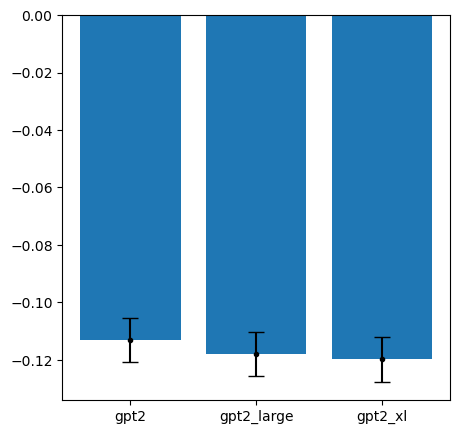

In [4]:
corrs = {model: [] for model in models}

subjs = human_data['subject'].unique()
for subj in subjs:
    subj_data = human_data[human_data['subject'] == subj]

    subj_resps = []
    model_resps = {model: [] for model in models}

    stim_ids = subj_data['stim_id'].unique()
    for stim_id in stim_ids:
        stim_subj = subj_data[subj_data['stim_id'] == stim_id]
        subj_resps.append(float(stim_subj['meanAmp_z'].iloc[0]))
        for model in models:
            surp = float(data[model][data[model]['stim_id'] == stim_id]['last_layer_surprisal'].iloc[0])
            model_resps[model].append(surp)

    for model in models:
        corrs[model].append(np.corrcoef(subj_resps, model_resps[model])[0, 1])

avgs = [np.mean(corrs[model]) for model in models]
sems = [stats.sem(corrs[model]) for model in models]
xs = list(range(len(models)))

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(xs, avgs)
ax.errorbar(xs, avgs, sems, capsize=6, color='black', fmt='.')
ax.set_xticks(xs)
ax.set_xticklabels(models)
plt.show()
plt.close()

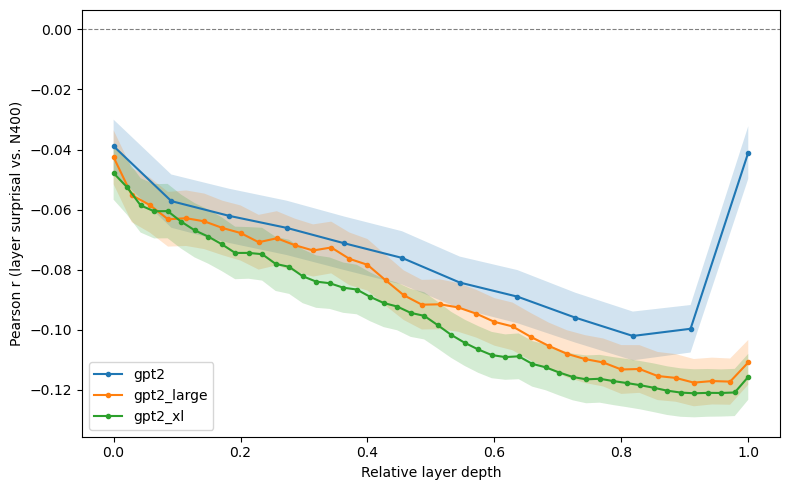

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for model in models:
    merged = human_data.merge(data[model], on='stim_id')
    layer_cols = sorted([c for c in merged.columns if c.startswith('layer_')])

    subj_corrs = []
    for subj in merged['subject'].unique():
        subj_df = merged[merged['subject'] == subj]
        subj_corrs.append([subj_df[col].corr(subj_df['meanAmp_z']) for col in layer_cols])

    subj_corrs = np.array(subj_corrs)  # (n_subjects, n_layers)
    avgs = subj_corrs.mean(axis=0)
    sems = stats.sem(subj_corrs, axis=0)

    n_layers = len(layer_cols)
    xs = np.linspace(0, 1, n_layers)

    ax.plot(xs, avgs, label=model, marker='o', markersize=3)
    ax.fill_between(xs, avgs - sems, avgs + sems, alpha=0.2)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Relative layer depth')
ax.set_ylabel('Pearson r (layer surprisal vs. N400)')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()